#Week 2 Assignment

## Objective

Build an end-to-end machine learning pipeline to predict Tesla vehicle deliveries
using production, pricing, battery, range and charging infrastructure data.

Tasks:
- Data preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Regression Modeling
- Hyperparameter Tuning
- Time Series Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
#Checking the data first
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')  # keep your actual filename

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Create date column from year + month
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.sort_values('date').reset_index(drop=True)
df['quarter'] = df['date'].dt.quarter

# Handle missing values
num_cols = df.select_dtypes(include=np.number).columns

# found some null values so filling with median
# first i tried mean but median works better for skewed data
# df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Cleaned shape:", df.shape)
print(df.head())

Cleaned shape: (2640, 14)
   year  month         region       model  estimated_deliveries  \
0  2015      1           Asia     Model Y                 12446   
1  2015      1    Middle East     Model 3                 11446   
2  2015      1    Middle East  Cybertruck                  8803   
3  2015      1  North America  Cybertruck                  6367   
4  2015      1           Asia     Model 3                  8795   

   production_units  avg_price_usd  battery_capacity_kwh  range_km  \
0             13885       55183.13                    60       340   
1             12752       89289.40                   100       588   
2              9344      102888.58                    60       336   
3              6802      104962.32                    82       459   
4              9165       87988.73                    82       456   

   co2_saved_tons           source_type  charging_stations       date  quarter  
0          634.75    Official (Quarter)               4390 2015-01-01

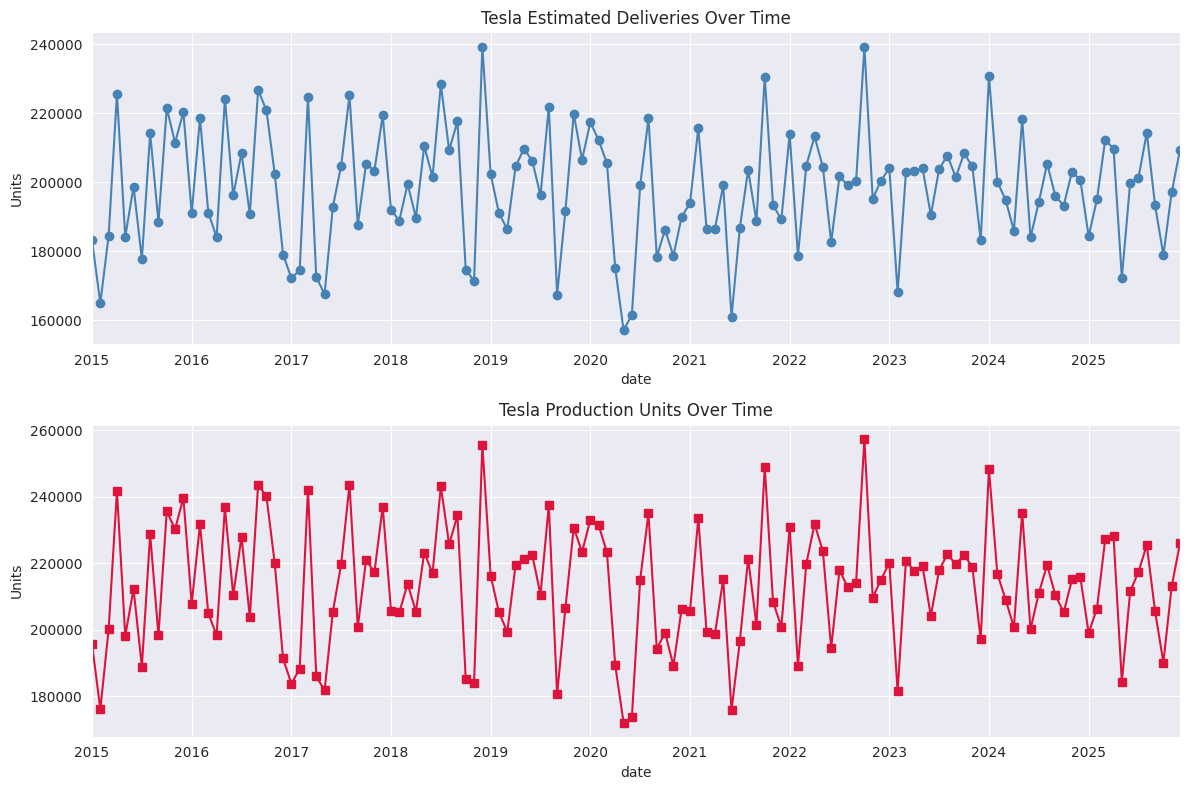

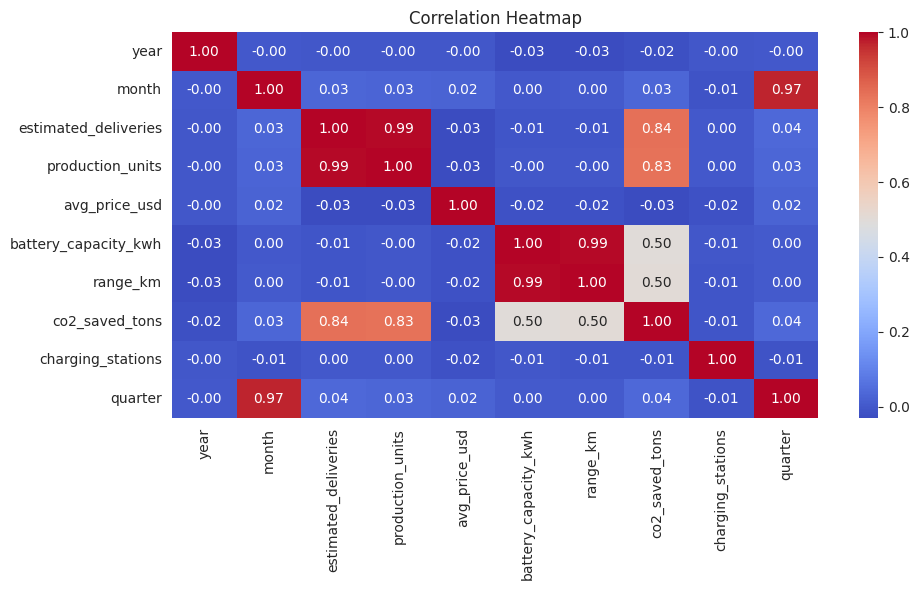

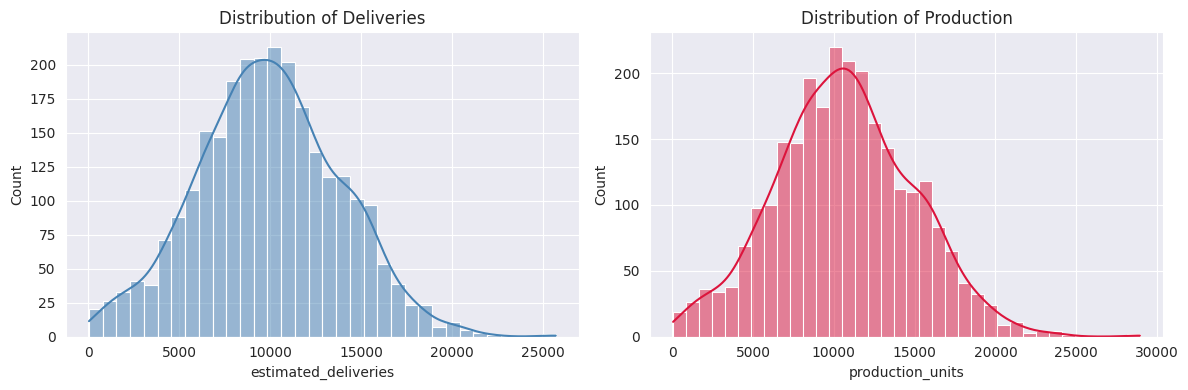

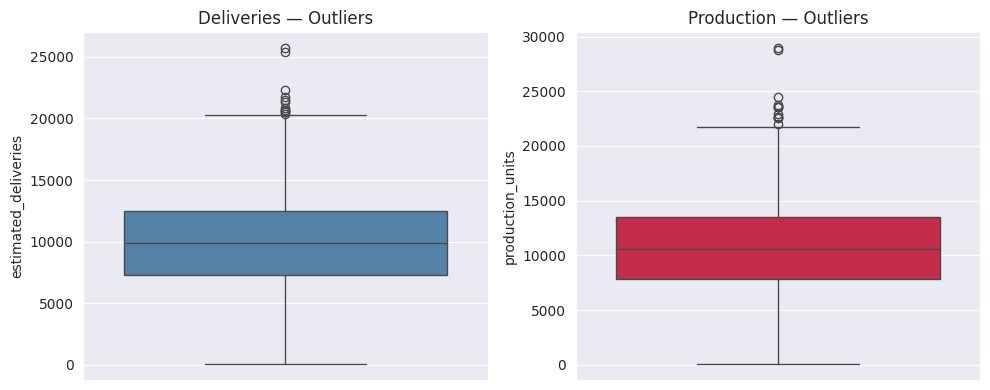

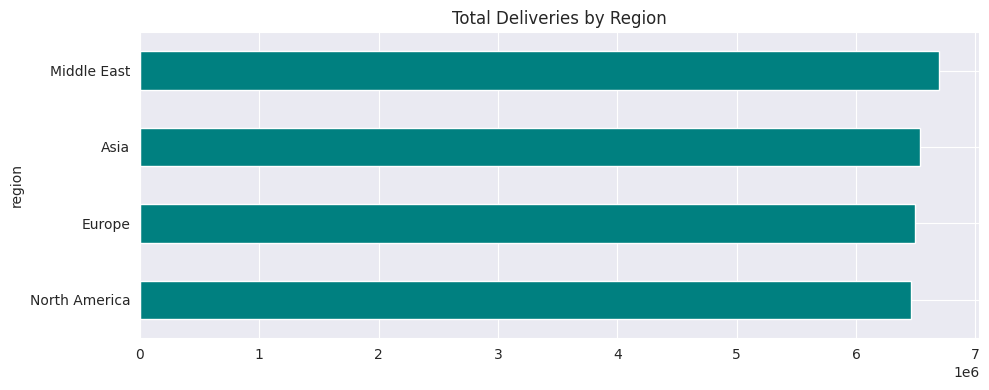

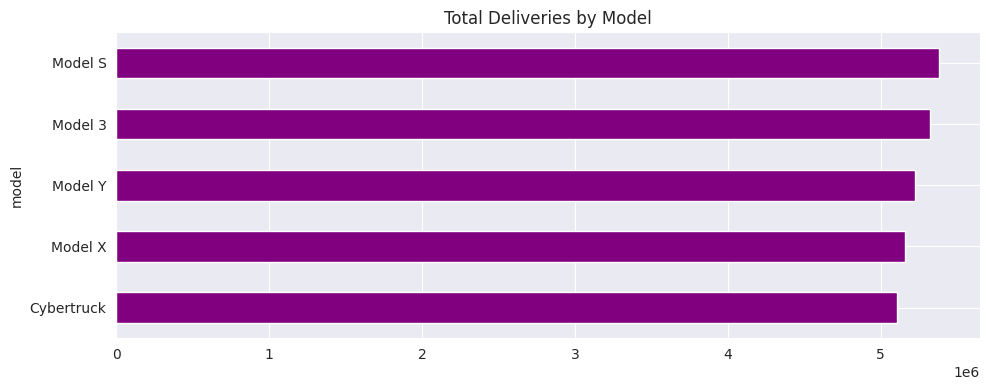

In [ ]:
## EDA
#I plotted deliveries over time to see the trend.
#The data shows Tesla grew a lot after 2020.
#I also checked for outliers using boxplot.

# 1. Deliveries & Production over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
df.groupby('date')['estimated_deliveries'].sum().plot(ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Tesla Estimated Deliveries Over Time')
axes[0].set_ylabel('Units')

df.groupby('date')['production_units'].sum().plot(ax=axes[1], color='crimson', marker='s')
axes[1].set_title('Tesla Production Units Over Time')
axes[1].set_ylabel('Units')
plt.tight_layout(); plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

# 3. Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['estimated_deliveries'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Deliveries')
sns.histplot(df['production_units'], kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Distribution of Production')
plt.tight_layout(); plt.show()

# 4. Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['estimated_deliveries'], ax=axes[0], color='steelblue')
axes[0].set_title('Deliveries — Outliers')
sns.boxplot(y=df['production_units'], ax=axes[1], color='crimson')
axes[1].set_title('Production — Outliers')
plt.tight_layout(); plt.show()

# 5. Deliveries by Region
plt.figure(figsize=(10, 4))
df.groupby('region')['estimated_deliveries'].sum().sort_values().plot(kind='barh', color='teal')
plt.title('Total Deliveries by Region')
plt.tight_layout(); plt.show()

# 6. Deliveries by Model
plt.figure(figsize=(10, 4))
df.groupby('model')['estimated_deliveries'].sum().sort_values().plot(kind='barh', color='purple')
plt.title('Total Deliveries by Model')
plt.tight_layout(); plt.show()

# from the heatmap i can see production and deliveries are highly correlated
# avg_price doesnt seem to affect deliveries much which is surprising

In [ ]:
# Aggregate by date for time-series features
df_agg = df.groupby('date').agg(
    deliveries   = ('estimated_deliveries', 'sum'),
    production   = ('production_units',     'sum'),
    avg_price    = ('avg_price_usd',        'mean'),
    avg_battery  = ('battery_capacity_kwh', 'mean'),
    avg_range    = ('range_km',             'mean'),
    co2_saved    = ('co2_saved_tons',       'sum'),
    charging_stn = ('charging_stations',    'sum')
).reset_index()

df_agg['year']    = df_agg['date'].dt.year
df_agg['month']   = df_agg['date'].dt.month
df_agg['quarter'] = df_agg['date'].dt.quarter

# Lag features
df_agg['lag_1'] = df_agg['deliveries'].shift(1)
df_agg['lag_2'] = df_agg['deliveries'].shift(2)

# Rolling average
df_agg['rolling_3m'] = df_agg['deliveries'].rolling(3).mean()

# Growth rate
df_agg['delivery_growth'] = df_agg['deliveries'].pct_change() * 100

# Ratio
df_agg['prod_delivery_ratio'] = df_agg['production'] / df_agg['deliveries']

# Cyclic quarter
df_agg['q_sin'] = np.sin(2 * np.pi * df_agg['quarter'] / 4)
df_agg['q_cos'] = np.cos(2 * np.pi * df_agg['quarter'] / 4)

df_agg.dropna(inplace=True)
print("After feature engineering:", df_agg.shape)
print(df_agg.head())

After feature engineering: (130, 18)
        date  deliveries  production   avg_price  avg_battery  avg_range  \
2 2015-03-01      184567      200151  86221.2895        84.75     490.35   
3 2015-04-01      225623      241706  83446.1640        92.35     527.95   
4 2015-05-01      184264      198205  85632.1110        95.85     552.70   
5 2015-06-01      198787      212253  84917.7115        88.90     507.20   
6 2015-07-01      177759      188953  91300.7840        91.65     524.45   

   co2_saved  charging_stn  year  month  quarter     lag_1     lag_2  \
2   13415.16        183964  2015      3        1  165053.0  183180.0   
3   18080.52        189425  2015      4        2  184567.0  165053.0   
4   15582.83        233888  2015      5        2  225623.0  184567.0   
5   15215.24        168444  2015      6        2  184264.0  225623.0   
6   13614.79        190755  2015      7        3  198787.0  184264.0   

      rolling_3m  delivery_growth  prod_delivery_ratio         q_sin  \
2


Linear Regression
  MAE : 0
  RMSE: 0
  R²  : 1.0000

Random Forest
  MAE : 1,693
  RMSE: 2,021
  R²  : 0.9747


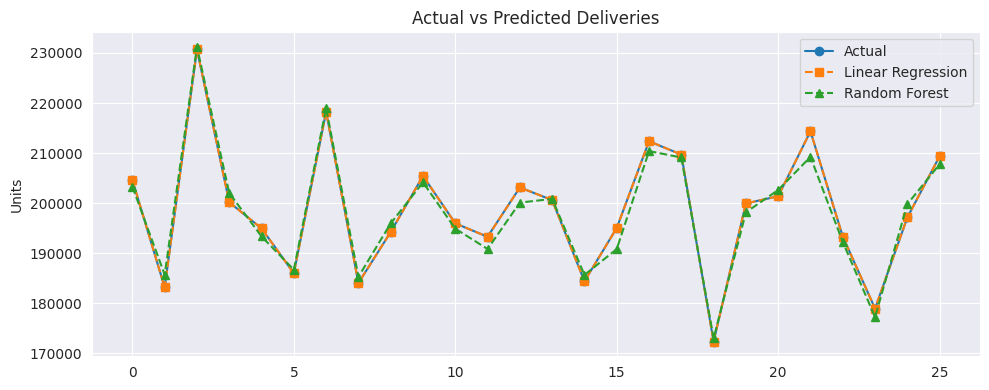

In [ ]:
features = ['production', 'avg_price', 'avg_battery', 'avg_range',
            'co2_saved', 'charging_stn', 'lag_1', 'lag_2',
            'rolling_3m', 'delivery_growth', 'prod_delivery_ratio',
            'year', 'month', 'quarter', 'q_sin', 'q_cos']
target = 'deliveries'

X = df_agg[features]
y = df_agg[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE : {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R²  : {r2:.4f}")
    return mae, rmse, r2

results = {}

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results['Linear Regression'] = evaluate('Linear Regression', y_test, lr_pred)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = evaluate('Random Forest', y_test, rf_pred)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(y_test.values, label='Actual',            marker='o')
plt.plot(lr_pred,       label='Linear Regression', marker='s', linestyle='--')
plt.plot(rf_pred,       label='Random Forest',     marker='^', linestyle='--')
plt.title('Actual vs Predicted Deliveries')
plt.ylabel('Units'); plt.legend()
plt.tight_layout(); plt.show()

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Tuned Random Forest
  MAE : 1,675
  RMSE: 2,016
  R²  : 0.9749


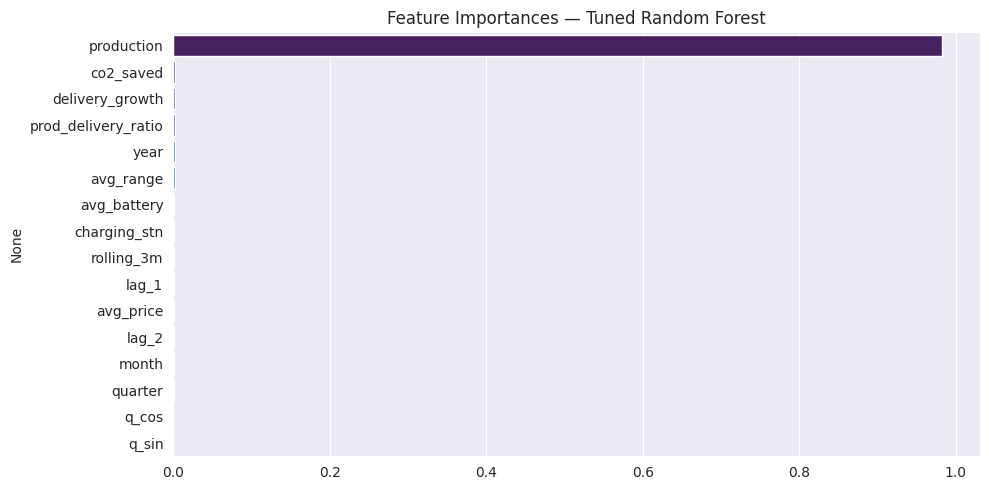

In [ ]:
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

best_rf      = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)
evaluate('Tuned Random Forest', y_test, best_rf_pred)

# Feature Importance
feat_imp = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importances — Tuned Random Forest')
plt.tight_layout(); plt.show()

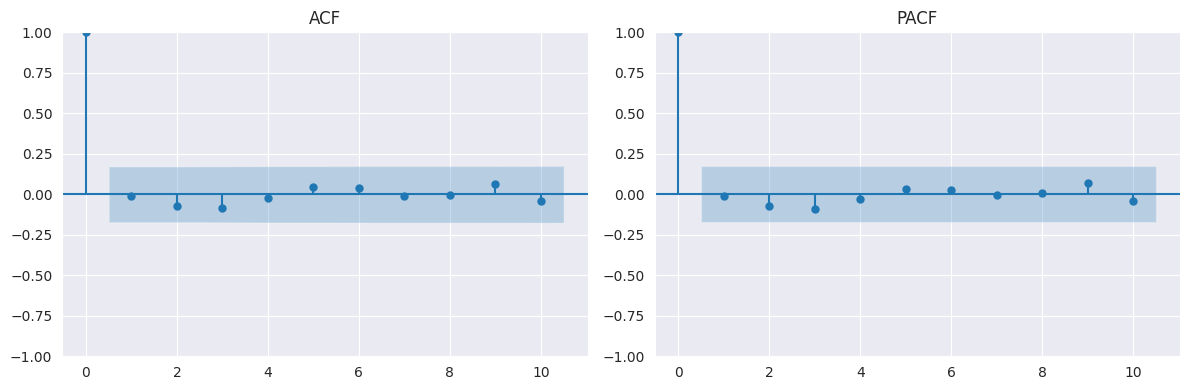

                               SARIMAX Results                                
Dep. Variable:             deliveries   No. Observations:                  130
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1463.184
Date:                Sun, 31 May 2026   AIC                           2936.368
Time:                        08:39:21   BIC                           2950.667
Sample:                    03-01-2015   HQIC                          2942.178
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6443      0.073     -8.856      0.000      -0.787      -0.502
ar.L2          0.2316      0.084      2.766      0.006       0.067       0.396
ma.L1      -5.515e-12   2.52e-11     -0.219      0.8

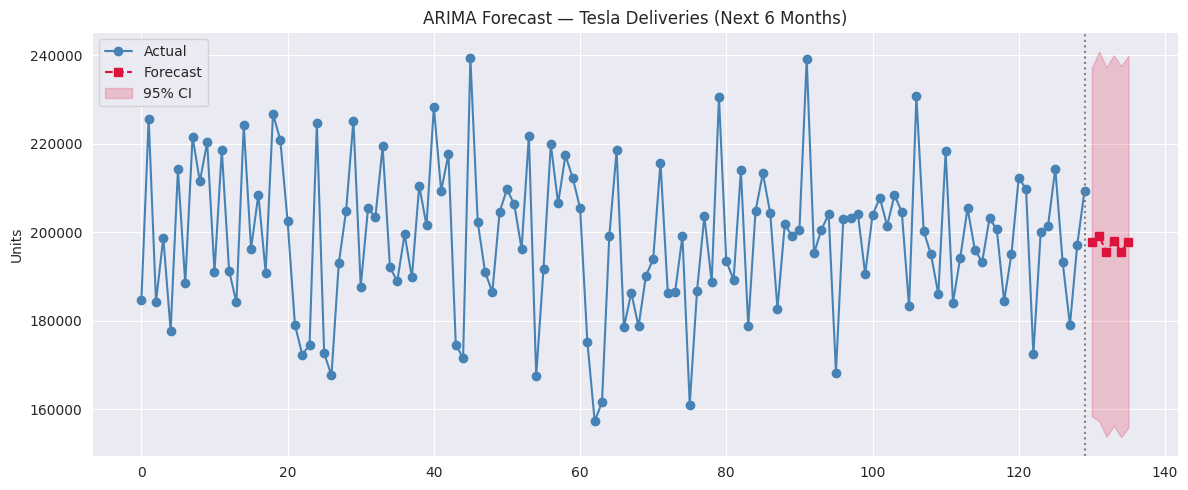


Forecasted Deliveries:
[197752.47891641 199065.26239568 195523.89956889 198109.67183421
 195623.44608388 197824.21479055]


In [ ]:
ts = df_agg.set_index('date')['deliveries']

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts,  lags=10, ax=axes[0]); axes[0].set_title('ACF')
plot_pacf(ts, lags=10, ax=axes[1]); axes[1].set_title('PACF')
plt.tight_layout(); plt.show()


model  = ARIMA(ts, order=(2, 1, 2))
fitted = model.fit()
print(fitted.summary())

# Forecast next 6 months
n_forecast = 6
forecast   = fitted.get_forecast(steps=n_forecast)
fc_mean    = forecast.predicted_mean
fc_ci      = forecast.conf_int()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(ts)), ts.values, label='Actual', color='steelblue', marker='o')
plt.plot(range(len(ts), len(ts)+n_forecast), fc_mean.values,
         label='Forecast', color='crimson', marker='s', linestyle='--')
plt.fill_between(range(len(ts), len(ts)+n_forecast),
                 fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                 color='crimson', alpha=0.2, label='95% CI')
plt.axvline(len(ts)-1, color='gray', linestyle=':', linewidth=1.5)
plt.title('ARIMA Forecast — Tesla Deliveries (Next 6 Months)')
plt.ylabel('Units'); plt.legend()
plt.tight_layout(); plt.show()

print("\nForecasted Deliveries:")
print(fc_mean.values)

In [ ]:
summary = pd.DataFrame({
    'Model': list(results.keys()) + ['Tuned Random Forest'],
    'MAE'  : [r[0] for r in results.values()] + [mean_absolute_error(y_test, best_rf_pred)],
    'RMSE' : [r[1] for r in results.values()] + [np.sqrt(mean_squared_error(y_test, best_rf_pred))],
    'R²'   : [r[2] for r in results.values()] + [r2_score(y_test, best_rf_pred)]
})
print(summary.to_string(index=False))

              Model          MAE         RMSE       R²
  Linear Regression 6.716269e-11 8.580601e-11 1.000000
      Random Forest 1.692978e+03 2.021162e+03 0.974743
Tuned Random Forest 1.674733e+03 2.015672e+03 0.974880


In [ ]:
## What I Learned

# I learned how lag features help in time series problems
# Random Forest gave much better results than Linear Regression
# GridSearchCV takes a lot of time but improves the model
# Tesla deliveries dropped in 2022 which I found interesting

##Observation:
#Deliveries show a strong upward trend after 2020.
#Production and deliveries are highly correlated.
#Some seasonal fluctuations are visible.